# One-sided (Bob-copies-only) SDP

Same sweeps as `sdp.ipynb`, run with `SDP_utils.sdp_bonly.SDP_bonly` (extension on $A\,B_1\dots B_k$ instead of $(AB)^{\otimes k}$). Results are written to the `sdp_results/<folder>_B` folders so they can be compared file-by-file with the two-sided ones. No upper bounds (there is no `SDP_max` for this variant).

Optional keyword arguments forwarded to `SDP_bonly` (all valid relaxations of the same convex roof):
- `extra_cut=True` — PPT across $A|B_1\dots B_k$, **valid for `lam=[1,1]`-type (SN>1) tests only**; makes NPT states infeasible.
- `reduction=True` — $\sigma \preceq r\,(\mathrm{tr}_{B_1}\sigma)\otimes I_{B_1}$ with $r=$ `len(lam)-1`.
- `marginal_symmetry=False` — drop the $S_k$-invariance of $\mathrm{tr}_A\sigma$ (not recommended: for SN>2 tests the SDP is then blind).

In [1]:
from notebook_utils import plot_robustness, plot_schmidt_number
from notebook_utils.run_SDP_B import run_sdp_on_range_B, bin_search_sdp_vertex_B
import numpy as np

# Test on $\mathbb{C}^2 \otimes \mathbb{C}^2$ isotropic state

0it [00:00, ?it/s]


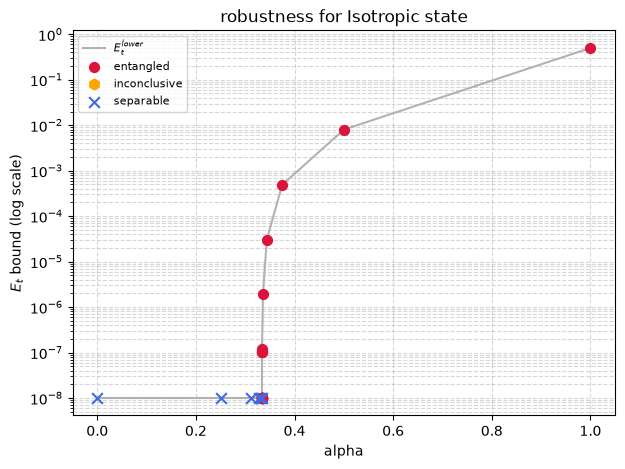

In [2]:
from toqito.states import isotropic

filename = "c2c2_Isotropic.jsonl"
bin_search_sdp_vertex_B(filename, (2, 2), [1, 1], lambda p: isotropic(2, p), (0, 1), 30, folder="test_B")
plot_robustness(filename, "robustness for Isotropic state", "alpha", folder="test_B")

# Test on $\mathbb{C}^3 \otimes \mathbb{C}^3$ states with noise and on Horodecki

In [3]:
from bound_entangled.c3_otimes_c3 import chessboard_extremal_PPT, cross_hatch, tiles_upb, pyramid_upb, horodecki, ncomms6297, steering_state
from toqito.states import max_mixed

## Horodecki state

0 points left to compute


0it [00:00, ?it/s]


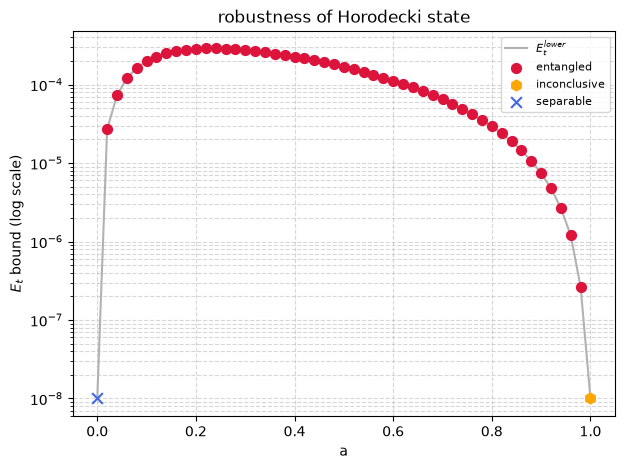

In [4]:
filename = "c3c3_Horodecki.jsonl"
range_ = (0, 1, 0.02)
run_sdp_on_range_B(filename, (3, 3), [1, 1], lambda p: horodecki(p), range_, folder="Parametric_B")
plot_robustness(filename, "robustness of Horodecki state", "a", range_=range_, folder="Parametric_B")

## States with added noise

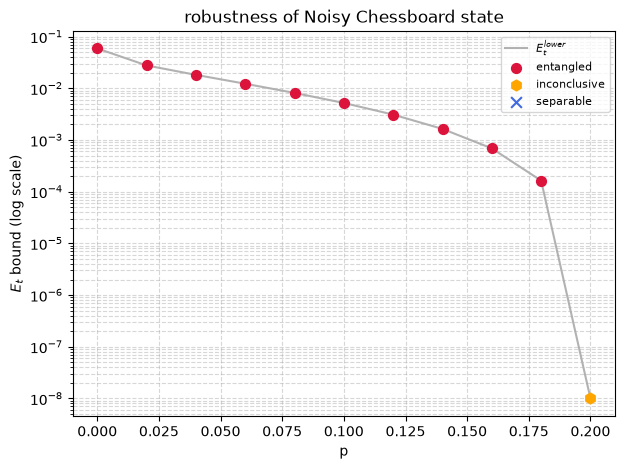

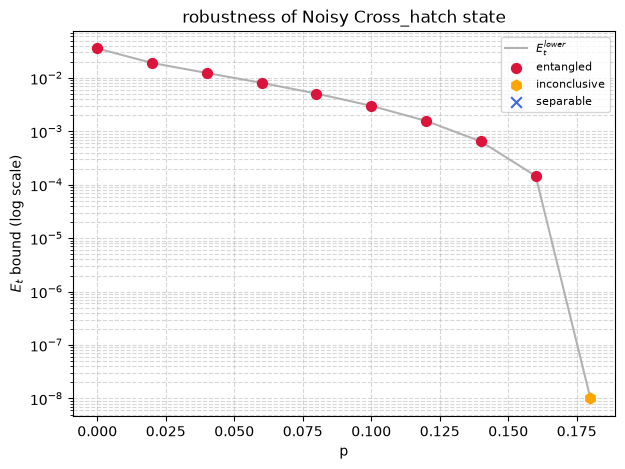

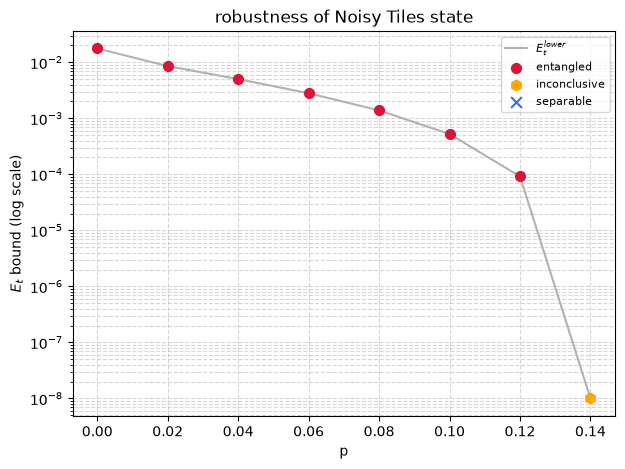

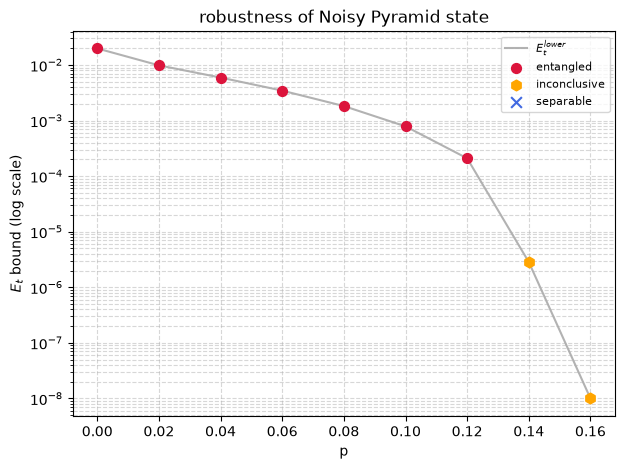

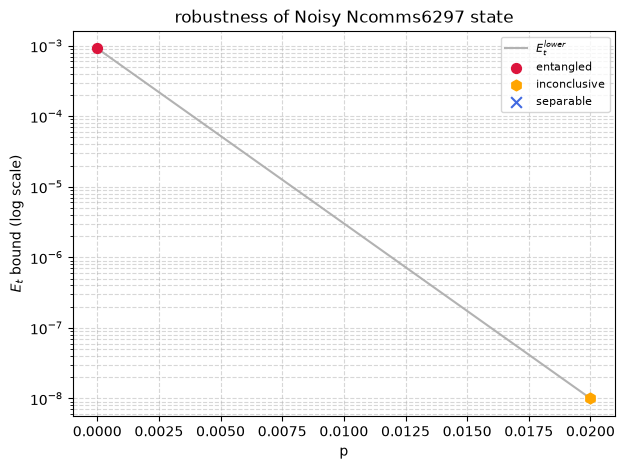

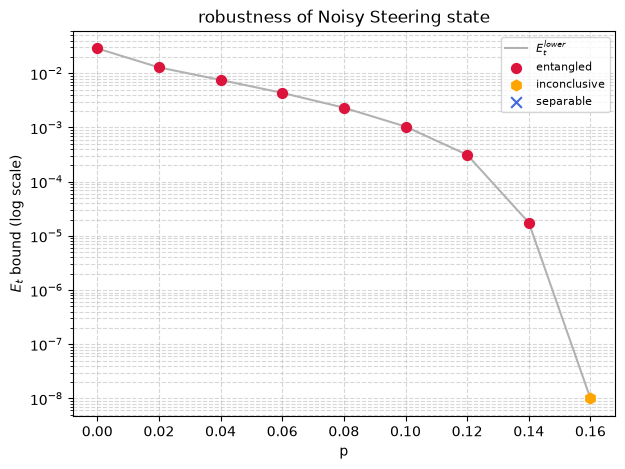

In [5]:
c3c3_non_parametric = [
    (chessboard_extremal_PPT(), "Chessboard"),
    (cross_hatch(), "Cross_hatch"),
    (tiles_upb(), "Tiles"),
    (pyramid_upb(), "Pyramid"),
    (ncomms6297(), "Ncomms6297"),
    (steering_state(0.4, 0.4), "Steering"),
]
maxmixed = max_mixed(3 * 3)

for state, name in c3c3_non_parametric:
    filename = f"{name}_with_noise.jsonl"
    run_sdp_on_range_B(filename, (3, 3), [1, 1], lambda p: state * (1 - p) + maxmixed * p, range_, early_stop=True, folder="noise_B")
    plot_robustness(filename, f"robustness of Noisy {name} state", "p", range_=range_, folder="noise_B")

0it [00:00, ?it/s]


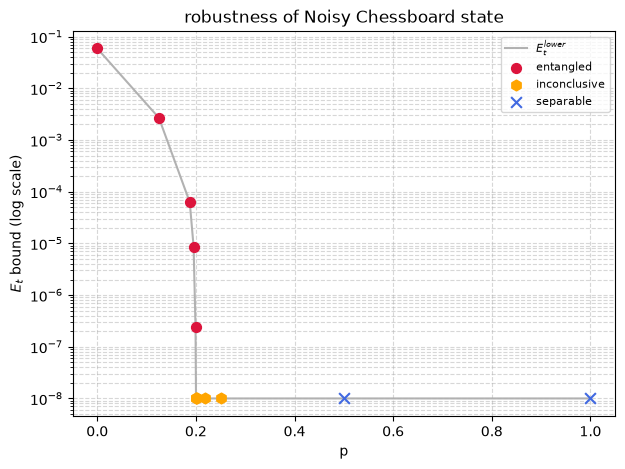

0it [00:00, ?it/s]


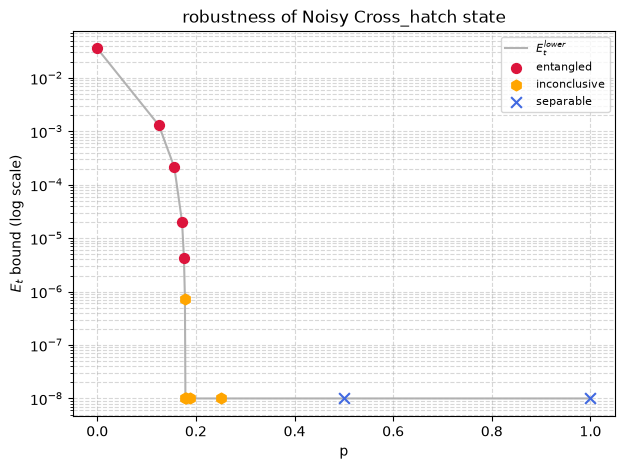

0it [00:00, ?it/s]


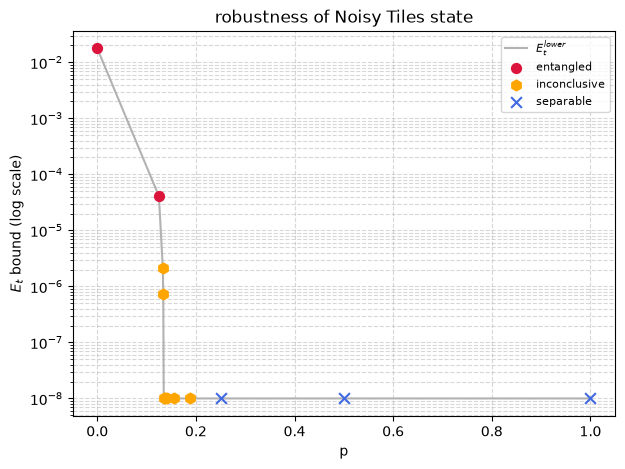

0it [00:00, ?it/s]


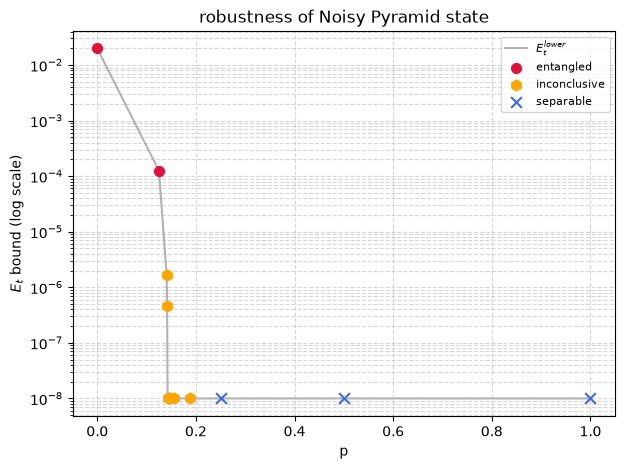

0it [00:00, ?it/s]


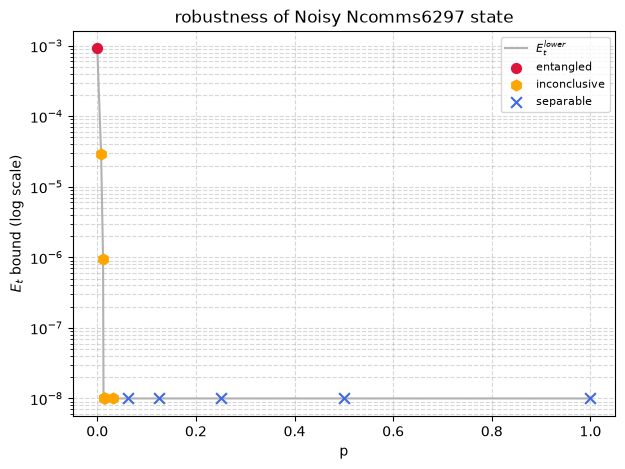

0it [00:00, ?it/s]


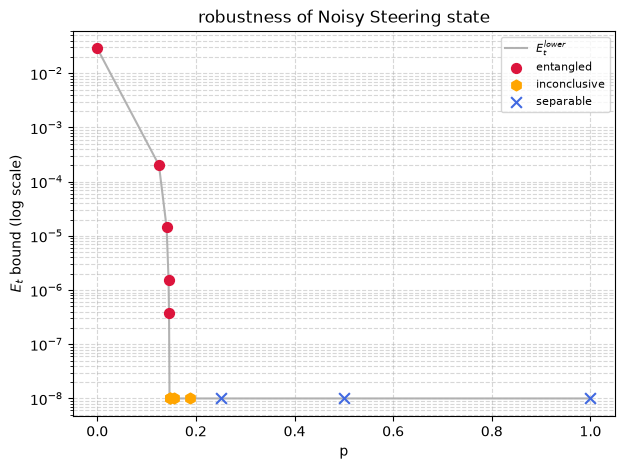

In [6]:
c3c3_non_parametric = [
    (chessboard_extremal_PPT(), "Chessboard"),
    (cross_hatch(), "Cross_hatch"),
    (tiles_upb(), "Tiles"),
    (pyramid_upb(), "Pyramid"),
    (ncomms6297(), "Ncomms6297"),
    (steering_state(0.4, 0.4), "Steering"),
]
maxmixed = max_mixed(3 * 3)

for state, name in c3c3_non_parametric:
    filename = f"{name}_with_noise_vertex.jsonl"
    bin_search_sdp_vertex_B(filename, (3, 3), [1, 1], lambda p: state * (1 - p) + maxmixed * p, (0, 1), 10, decreasing=True, folder="vertex_B")
    plot_robustness(filename, f"robustness of Noisy {name} state", "p", folder="vertex_B")

## Convex combinations of PPT states

In [ ]:
from itertools import combinations

c3c3_non_parametric = [
    (chessboard_extremal_PPT(), "Chessboard"),
    (cross_hatch(), "Cross_hatch"),
    (tiles_upb(), "Tiles"),
    (pyramid_upb(), "Pyramid"),
    (steering_state(0.4, 0.4), "Steering"),
]
for (st1, n1), (st2, n2) in combinations(c3c3_non_parametric, 2):
    filename = f"convex_{n1}_{n2}.jsonl"
    run_sdp_on_range_B(filename, (3, 3), [1, 1], lambda p: st1 * (1 - p) + st2 * p, range_, folder="convex_B", k_sym_depth=2)
    plot_robustness(filename, f"Convex Combination between {n1} (left) and {n2} (right)", "p", range_=range_, folder="convex_B")

# Test on $\mathbb{C}^3 \otimes \mathbb{C}^3$ states with noise and on Horodecki with lambda \[2,1\]

In [8]:
# range_ = (0, 1, 0.1)
# filename = "c3c3_Horodecki_lam21.jsonl"
# range_ = (0, 1, 0.05)
# run_sdp_on_range_B(filename, (3, 3), [2, 1], lambda p: horodecki(p), range_, folder="lam21_B")
# plot_robustness(filename, "robustness of Horodecki state", "a", range_=range_, folder="lam21_B")


# c3c3_non_parametric = [
#     (chessboard_extremal_PPT(), "Chessboard"),
#     (cross_hatch(), "Cross_hatch"),
#     (tiles_upb(), "Tiles"),
#     (pyramid_upb(), "Pyramid"),
#     (ncomms6297(), "Ncomms6297"),
# ]
# maxmixed = max_mixed(3 * 3)
# for state, name in c3c3_non_parametric:
#     filename = f"{name}_with_noise_lam21.jsonl"
#     run_sdp_on_range_B(filename, (3, 3), [2, 1], lambda p: state * (1 - p) + maxmixed * p, range_, early_stop=True, folder="lam21_B")
#     plot_robustness(filename, f"robustness of Noisy {name} state", "p", range_=range_, folder="lam21_B")

# from itertools import combinations

# c3c3_non_parametric = [(chessboard_extremal_PPT(), "Chessboard"), (cross_hatch(), "Cross_hatch"), (tiles_upb(), "Tiles"), (pyramid_upb(), "Pyramid")]
# for (st1, n1), (st2, n2) in combinations(c3c3_non_parametric, 2):
#     filename = f"convex_{n1}_{n2}_lam21.jsonl"
#     run_sdp_on_range_B(filename, (3, 3), [2, 1], lambda p: st1 * (1 - p) + st2 * p, range_, folder="lam21_B")
#     plot_robustness(filename, f"Convex Combination between {n1} (left) and {n2} (right)", "p", range_=range_, folder="lam21_B")

# Test on $\mathbb{C}^4 \otimes \mathbb{C}^4$ states with noise + Breur

6 points left to compute


100%|██████████| 6/6 [08:44<00:00, 87.38s/it]


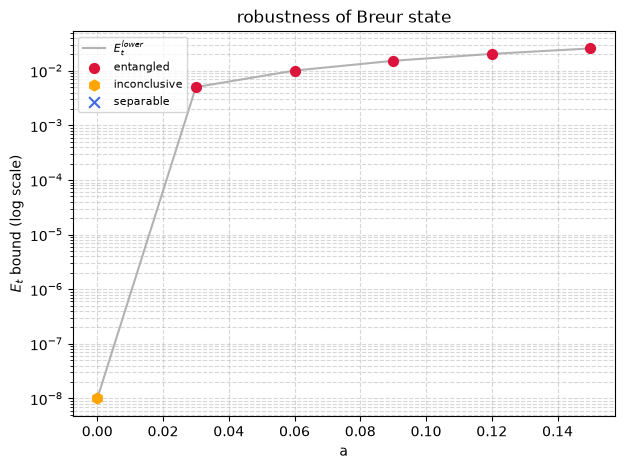

In [9]:
from bound_entangled.c4_otimes_c4 import piani
from bound_entangled.cd_otimes_cd import gen_tiles1, yu_oh
from bound_entangled.cm_otimes_cn import gen_tiles2
from toqito.states import breuer

filename = "Breur.jsonl"
range_ = (0, 1/(4+2), 0.03)
run_sdp_on_range_B(filename, (4, 4), [1, 1], lambda p: breuer(4, p), range_, folder="Parametric_B")
plot_robustness(filename, "robustness of Breur state", "a", range_=range_, folder="Parametric_B")

26 points left to compute


 38%|███▊      | 10/26 [02:56<04:42, 17.65s/it]


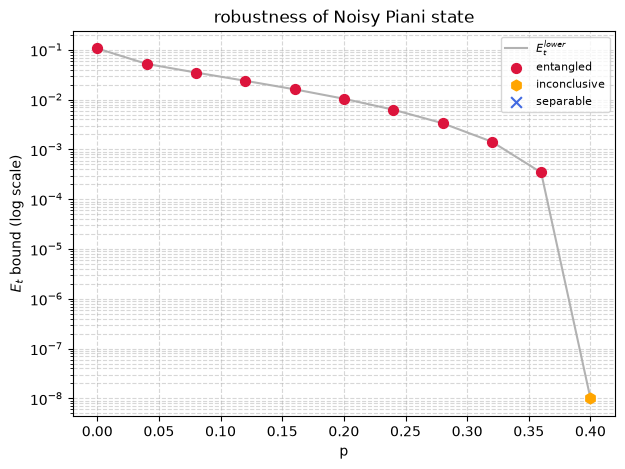

26 points left to compute


 15%|█▌        | 4/26 [02:39<14:35, 39.77s/it]


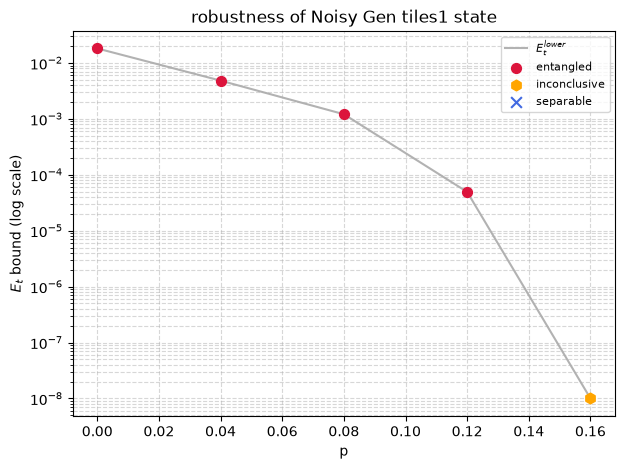

26 points left to compute


 12%|█▏        | 3/26 [01:12<07:08, 18.63s/it]/Users/anton/Desktop/GitHub/QuantifyingSchmidtNumber/.venv/lib/python3.13/site-packages/toqito/state_props/has_symmetric_extension.py:168: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve()
 15%|█▌        | 4/26 [07:17<40:04, 109.28s/it]


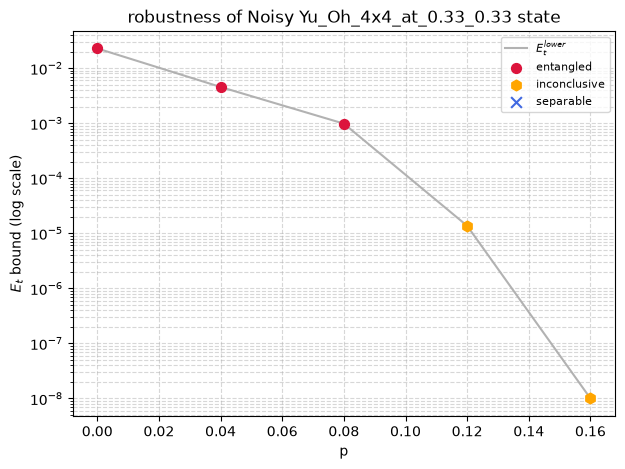

26 points left to compute


 15%|█▌        | 4/26 [02:36<14:18, 39.01s/it]


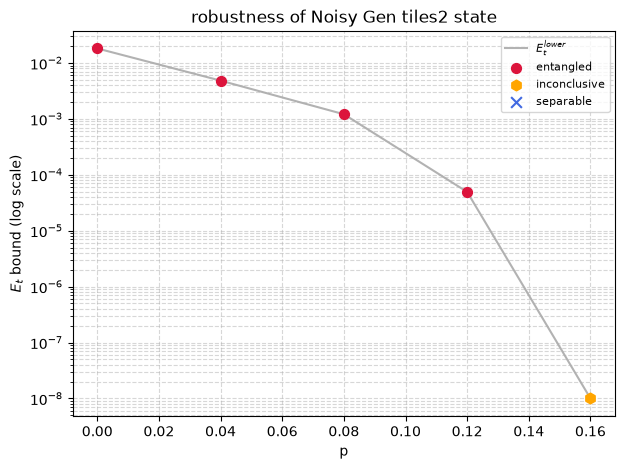

In [10]:
range_ = (0, 1, 0.04)
c4c4_states: list[tuple[np.ndarray, str]] = [
    (piani(), "Piani"),
    (gen_tiles1(full_dim=4), "Gen tiles1"),
    (yu_oh(full_dim=4, x=1 / 3, y=1 / 3), "Yu_Oh_4x4_at_0.33_0.33"),
    (gen_tiles2((4, 4)), "Gen tiles2"),
]
maxmixed = max_mixed(4 * 4)
for state, name in c4c4_states:
    filename = f"{name}_with_noise.jsonl"
    run_sdp_on_range_B(filename, (4, 4), [1, 1], lambda p: state * (1 - p) + maxmixed * p, range_, early_stop=True, folder="noise_B")
    plot_robustness(filename, f"robustness of Noisy {name} state", "p", range_=range_, folder="noise_B")

# Test on $\mathbb{C}^3 \otimes \mathbb{C}^3$ Isotropic state.

According to https://arxiv.org/pdf/quant-ph/9911117 theorem 2
$$SN(\rho) = k \iff \frac{k-1}{d} < F < \frac{k}{d}$$

$$\text{SN}(\rho_F) = \begin{cases} 
1 & 0 \le F \le \tfrac{1}{3} \quad (\text{separable})\\
2 & \tfrac{1}{3} < F \le \tfrac{2}{3}\\
3 & \tfrac{2}{3} < F \le 1 
\end{cases}$$

100%|██████████| 15/15 [00:00<00:00, 18.40it/s]


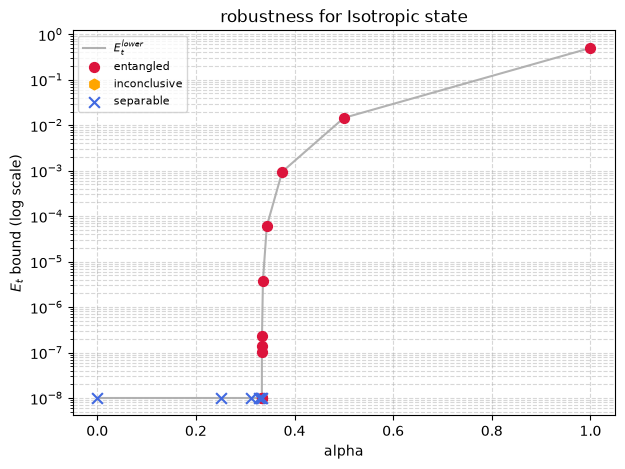

100%|██████████| 10/10 [42:06<00:00, 252.70s/it]


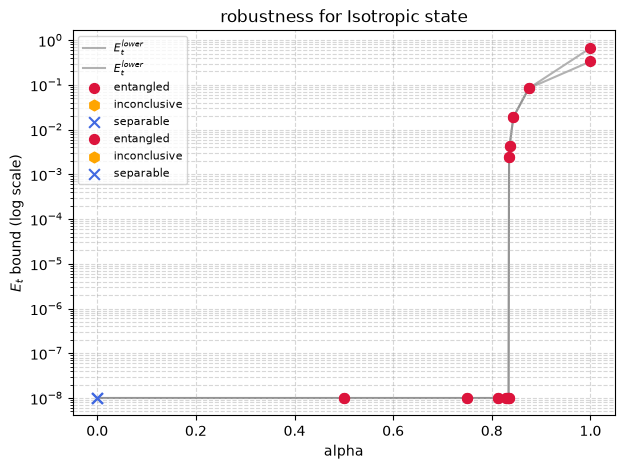

In [11]:
from toqito.states import isotropic as isoA


def isotropic(F):
    alpha = (9 * F - 1) / 8
    return isoA(3, alpha)


filename = "c3c3_isotropicSN2_bin.jsonl"
bin_search_sdp_vertex_B(filename, (3, 3), [1, 1], lambda F: isotropic(F),(0,1), 15, folder="test_B")
plot_robustness(filename, "robustness for Isotropic state", "alpha", folder="test_B")

filename = "c3c3_isotropicSN3_bin.jsonl"
bin_search_sdp_vertex_B(filename, (3, 3), [1, 1, 1], lambda F: isotropic(F),(0,1), 10, folder="SN3_B")
plot_robustness(filename, "robustness for Isotropic state", "alpha", folder="SN3_B")

100%|██████████| 15/15 [2:52:22<00:00, 689.51s/it]  


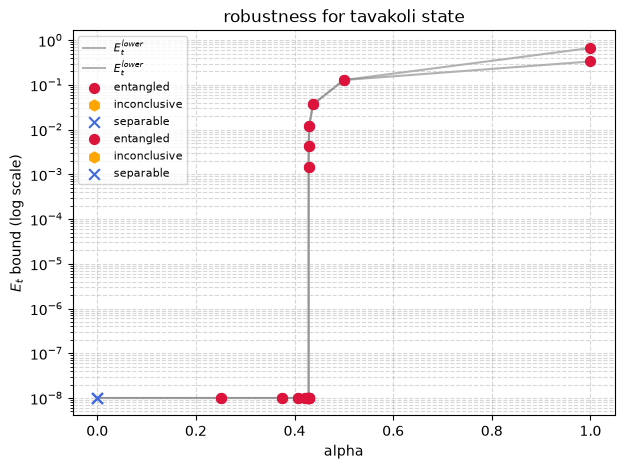

In [12]:
from tavako import tavakoli_morelli_state

filename = "tavakoli_bin.jsonl"
bin_search_sdp_vertex_B(filename, (3, 3), [1, 1, 1], lambda q: tavakoli_morelli_state(q), (0,1), 15, folder="SN3_B")
plot_robustness(filename, "robustness for tavakoli state", "alpha",folder="SN3_B")